# Capítulo 2 — Ejercicios resueltos

Soluciones de los 10 ejercicios de la sección 2.6, con la explicación de **por qué** sale así.

Los enunciados (sin resolver) están en `02_introduccion.ipynb`. Este notebook es autocontenido:
recarga los datos y redefine lo que hace falta.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import rdkit, rdkit.Chem, rdkit.Chem.Draw
from rdkit.Chem.Draw import IPythonConsole
import sklearn.cluster, sklearn.decomposition

soldata = pd.read_csv("../data/curated-solubility-dataset.csv")
features_start_at = list(soldata.columns).index("MolWt")
feature_names = soldata.columns[features_start_at:]

X = jnp.array(soldata[feature_names].values, dtype=jnp.float32)
y = jnp.array(soldata["Solubility"].values, dtype=jnp.float32)
X_std = (X - X.mean(axis=0)) / X.std(axis=0)


def linear_model(x, w, b):
    return jnp.dot(x, w) + b


def loss(y_pred, labels):
    return jnp.mean((y_pred - labels) ** 2)


def loss_wrapper(w, b, X, labels):
    return loss(linear_model(X, w, b), labels)


loss_grad = jax.jit(jax.grad(loss_wrapper, (0, 1)))

print("datos:", X.shape, y.shape)

datos: (9982, 17) (9982,)


---
## 2.6.1 Datos

### Ejercicio 1 — estadísticos de cada feature

> Calcula la media, el mínimo, el máximo y la desviación típica **de cada feature**.

In [2]:
# La clave: X es (9982, 17) y queremos 17 números. Luego el eje que debe DESAPARECER
# es el 0 (el de las moléculas): axis=0.
medias = np.mean(X, axis=0)
minimos = np.min(X, axis=0)
maximos = np.max(X, axis=0)
desviaciones = np.std(X, axis=0)

print(f"formas: {medias.shape} <- 17 números por estadístico\n")
print(f"{'feature':22s} {'media':>10s} {'mín':>10s} {'máx':>10s} {'std':>10s} {'rango/std':>10s}")
print("-" * 78)
for i, nombre in enumerate(feature_names):
    print(f"{nombre:22s} {medias[i]:10.2f} {minimos[i]:10.2f} {maximos[i]:10.2f} "
          f"{desviaciones[i]:10.2f} {(maximos[i] - minimos[i]) / desviaciones[i]:10.1f}")

formas: (17,) <- 17 números por estadístico

feature                     media        mín        máx        std  rango/std
------------------------------------------------------------------------------
MolWt                      266.67       9.01    5299.46     184.17       28.7
MolLogP                      1.98     -40.87      68.54       3.52       31.1
MolMR                       66.79       0.00    1419.35      46.52       30.5
HeavyAtomCount              17.37       1.00     388.00      12.24       31.6
NumHAcceptors                3.49       0.00      86.00       3.50       24.6
NumHDonors                   1.11       0.00      26.00       1.49       17.5
NumHeteroatoms               5.20       0.00      89.00       4.74       18.8
NumRotatableBonds            4.07       0.00     141.00       5.65       25.0
NumValenceElectrons         94.24       0.00    2012.00      64.75       31.1
NumAromaticRings             1.07       0.00      35.00       1.31       26.7
NumSaturatedRings 

**Por qué `axis=0`.** Es el punto del ejercicio, y viene directo del capítulo 1: **`axis=k`
significa "el eje k desaparece"**. `X` es `(9982, 17)`; si queremos un número por feature, lo que
tiene que colapsar son las 9982 moléculas, o sea el eje 0. El resultado es `(17,)`.

Si te sale `(9982,)` es que pusiste `axis=1` y has calculado la media de los 17 descriptores de cada
molécula, que no significa nada (¿la media entre un peso molecular y un contador de anillos?).

**Qué dicen los números.** He añadido una columna, `rango/std`, que mide cuántas desviaciones
típicas caben entre el mínimo y el máximo. Sirve para detectar distribuciones con colas largas:

- Descriptores de tamaño (`MolWt`, `BertzCT`, `LabuteASA`): ratio de 25-30. Muchísimo. Confirma lo
  que ya vimos — la mayoría de las moléculas son normalitas y hay unas pocas gigantes que estiran
  el rango.
- Contadores de anillos: ratios más pequeños, porque son enteros pequeños.
- `MolLogP` tiene mínimo negativo (hidrófilas) y máximo muy positivo: es el único descriptor que
  cambia de signo de forma informativa.

Y sobre todo: mira la columna de **medias**, de 0.29 a 467, y la de **std**, de 0.88 a 547. Esa
disparidad es exactamente la que ahogó el entrenamiento en 2.3.6 y la que arregló estandarizar.

### Ejercicio 2 — las dos moléculas más pesadas

> Dibújalas con RDKit. Tienen un aspecto raro; explica por qué.

1,4-xylene 4-(methoxycarbonyl)benzoic acid 4-methylbenzoic acid benzoi
   MolWt = 5299   Solubilidad = -6.73
   fragmentos desconectados en el SMILES: 24

hexasodium; dioxido-dioxotungsten; trioxotungsten
   MolWt = 2968   Solubilidad = -0.47
   fragmentos desconectados en el SMILES: 18



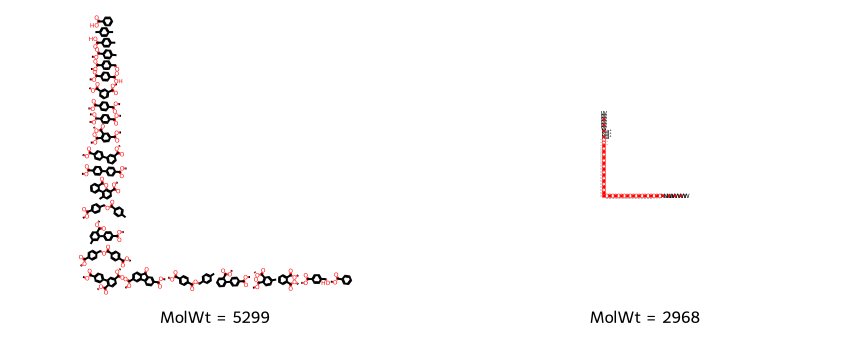

In [3]:
mas_pesadas = soldata.nlargest(2, "MolWt")

for _, fila in mas_pesadas.iterrows():
    n_fragmentos = fila["SMILES"].count(".") + 1
    print(f"{fila['Name'][:70]}")
    print(f"   MolWt = {fila['MolWt']:.0f}   Solubilidad = {fila['Solubility']:+.2f}")
    print(f"   fragmentos desconectados en el SMILES: {n_fragmentos}")
    print()

mols = [rdkit.Chem.MolFromInchi(i) for i in mas_pesadas["InChI"]]
rdkit.Chem.Draw.MolsToGridImage(
    mols, molsPerRow=2, subImgSize=(430, 340),
    legends=[f"MolWt = {m:.0f}" for m in mas_pesadas["MolWt"]]
)

**El aspecto raro: no son moléculas, son mezclas.**

- La primera pesa **5299** y su SMILES tiene **23 puntos**, o sea **24 fragmentos desconectados**.
  El nombre ya lo canta: *"1,4-xylene · 4-(methoxycarbonyl)benzoic acid · 4-methylbenzoic acid · ..."*.
  Es una mezcla industrial de veinticuatro compuestos metida como una fila del CSV.
- La segunda pesa **2968** y tiene **18 fragmentos**: es un **tungstato de sodio**,
  `[Na+].[Na+]....[O-][W]([O-])(=O)=O...`. Aquí no es una mezcla sino una **sal**, y los fragmentos
  son los iones sueltos.

Recuerda del capítulo 1 (y de 2.3.1): en SMILES el punto significa "componentes desconectados", y
RDKit los mete todos en **un solo objeto `Mol`**. Por eso el dibujo sale como una galería de
moléculas sueltas en vez de una estructura.

**Y aquí está la consecuencia grave para el ML:** todos los descriptores se calculan **sobre la
suma de los fragmentos**. Ese `MolWt = 5299` no es el peso de ninguna molécula real — es la suma de
24. Lo mismo pasa con `MolLogP`, `TPSA` y el resto.

Es exactamente el problema que destapamos en 2.3.9 al mirar las peores predicciones: el modelo ve
un peso molecular imposible y dispara a −29. **Este ejercicio es la versión "mirando los datos" de
aquel hallazgo "mirando los residuos"** — dos caminos distintos al mismo problema, que es justo la
moraleja de todo el capítulo.

Detalle bonito: fíjate en la solubilidad del tungstato, **−0.47**. Es una sal muy soluble, y sin
embargo tiene el segundo peso molecular del dataset. Para el modelo lineal, que asocia peso alto
con insolubilidad, esta molécula es veneno puro.

---
## 2.6.2 Modelos lineales

### Ejercicio 3 — demuestra que $y = w_1\sin(x) + w_2 x + b$ es un modelo lineal

**La respuesta.** "Lineal" en machine learning **no** quiere decir "una recta en $x$". Quiere decir
**lineal en los parámetros** $\vec{w}$, que son la incógnita del problema.

Comprobación formal: un modelo es lineal en $\vec{w}$ si cumple
$\hat{f}(\vec{x};\, \alpha\vec{w}_a + \beta\vec{w}_b) = \alpha \hat{f}(\vec{x};\vec{w}_a) + \beta \hat{f}(\vec{x};\vec{w}_b)$.
Aquí se cumple: $\sin(x)$ y $x$ son constantes respecto a $\vec{w}$, y solo aparecen multiplicando
a $w_1$ y $w_2$.

La manera práctica de verlo es **redefiniendo el vector de features**:

$$\vec{x}\,' = \begin{bmatrix} \sin(x) \\ x \end{bmatrix}, \qquad
\vec{w} = \begin{bmatrix} w_1 \\ w_2 \end{bmatrix}
\qquad\Longrightarrow\qquad y = \vec{w} \cdot \vec{x}\,' + b$$

Y eso es literalmente el mismo modelo lineal de 2.3.5, con $D = 2$.

**La no linealidad está en las features, no en el modelo.** Transformas la entrada con la función
que quieras —$\sin$, $\log$, $x^2$, la raíz cuadrada, el producto $x_1 x_2$— y el modelo sigue
siendo lineal y se sigue entrenando igual. A esas features fabricadas se las llama **basis
functions** (funciones de base).

> Esta idea es la que sostiene el **capítulo 5 (kernel learning)**, y también explica por qué las
> redes neuronales necesitan funciones de activación: **apilar capas lineales no sirve de nada**,
> porque la composición de dos funciones lineales es otra función lineal. La no linealidad tiene
> que meterse a mano, o transformando las features (aquí, capítulo 5) o metiendo una activación
> entre capas (capítulo 7).

Vamos a comprobarlo entrenándolo:

X_basis.shape = (300, 2)  <- 300 ejemplos, 2 features



parámetros recuperados: w1 = 2.991, w2 = -0.502, b = 2.002
parámetros verdaderos:  w1 = 3.000, w2 = -0.500, b = 2.000


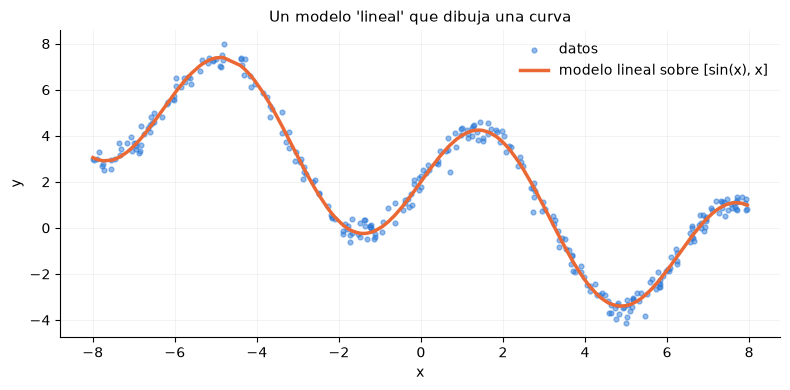

In [4]:
# datos sintéticos generados por y = 3*sin(x) - 0.5*x + 2  (+ ruido)
rng = np.random.default_rng(0)
x_raw = rng.uniform(-8, 8, 300)
y_raw = 3 * np.sin(x_raw) - 0.5 * x_raw + 2 + rng.normal(0, 0.3, 300)

# el truco: construimos la MATRIZ DE FEATURES [sin(x), x]
X_basis = jnp.array(np.stack([np.sin(x_raw), x_raw], axis=1), dtype=jnp.float32)
y_basis = jnp.array(y_raw, dtype=jnp.float32)
print("X_basis.shape =", X_basis.shape, " <- 300 ejemplos, 2 features")

# y ahora entrenamos con EXACTAMENTE el mismo codigo lineal de 2.3.6
w, b = jnp.zeros(2), 0.0
for paso in range(3000):
    gw, gb = loss_grad(w, b, X_basis, y_basis)
    w, b = w - 0.02 * gw, b - 0.02 * gb

print(f"\nparámetros recuperados: w1 = {w[0]:.3f}, w2 = {w[1]:.3f}, b = {b:.3f}")
print(f"parámetros verdaderos:  w1 = 3.000, w2 = -0.500, b = 2.000")

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x_raw, y_raw, s=12, alpha=0.5, color="#2a78d6", label="datos")
orden = np.argsort(x_raw)
ax.plot(x_raw[orden], np.array(linear_model(X_basis, w, b))[orden],
        color="#eb6834", linewidth=2.5, label="modelo lineal sobre [sin(x), x]")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Un modelo 'lineal' que dibuja una curva", fontsize=11)
ax.legend(frameon=False)
ax.grid(alpha=0.2, linewidth=0.5)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig("../figuras/02_ej3_basis.png", dpi=150)
plt.show()

Recupera los tres parámetros verdaderos (3.0, −0.5, 2.0) con el **mismo código de entrenamiento sin
tocar una línea**, y el resultado es una curva ondulada. Ahí está la demostración: el modelo es
lineal, la curva la ponen las features.

### Ejercicio 4 — el modelo en notación de Einstein con índice de batch

**La respuesta:**

$$ \hat{y}_b = x_{bi}\, w_i + b $$

y en código:

```python
y_pred = jnp.einsum("bi,i->b", X, w) + b
```

**Por qué.** Los índices son:

- $b$ = índice del ejemplo dentro del lote (*batch*), de 0 a $N-1$.
- $i$ = índice de la feature, de 0 a 16.

En la entrada aparecen $b$ e $i$; en la salida solo $b$. Por la regla del capítulo 1, **el índice
que no está en la salida se suma**: se suma sobre $i$, o sea sobre las 17 features. Y $b$, que está
en la entrada y en la salida, **no se suma**: la operación se repite para cada molécula por
separado.

Que es exactamente lo que queremos — una predicción por molécula, cada una sumando sus 17
contribuciones.

*(Ojo al choque de notación: la $b$ del batch y la $b$ del bias son cosas distintas y el libro usa
la misma letra. En la ecuación de arriba, $x_{bi}$ lleva la $b$ de batch y el $+\,b$ suelto es el
bias.)*

In [5]:
w_prueba = jnp.array(np.random.default_rng(0).normal(size=17), dtype=jnp.float32)
b_prueba = 1.5

con_einsum = jnp.einsum("bi,i->b", X_std, w_prueba) + b_prueba
con_dot = linear_model(X_std, w_prueba, b_prueba)

print("einsum ->", con_einsum.shape, " dot ->", con_dot.shape)
print("¿idénticos?", bool(jnp.allclose(con_einsum, con_dot, atol=1e-4)))
print("\nprimeras 3 predicciones:", np.array(con_einsum[:3]).round(4))

einsum -> (9982,)  dot -> (9982,)
¿idénticos? True

primeras 3 predicciones: [ 7.7188 -1.9604  1.9801]


---
## 2.6.3 Minimizar la pérdida

### Ejercicio 5 — ¿estandarizar las labels cambia el learning rate?

**La respuesta corta: no.** Y es un resultado bonito, porque la intuición dice que sí.

**La demostración.** Llama $\sigma$ a la desviación típica de las labels y define
$y' = (y - \bar{y})/\sigma$. Si además reescalas los parámetros como $\vec{w}\,' = \vec{w}/\sigma$ y
$b' = (b - \bar{y})/\sigma$, entonces cada residuo se divide por $\sigma$:

$$ \hat{y}\,'_i - y'_i = \frac{(\hat{y}_i - y_i)}{\sigma} \qquad\Longrightarrow\qquad L' = \frac{L}{\sigma^2} $$

La pérdida se divide por $\sigma^2$. Ahora la regla de la cadena, con $L'(\vec{w}\,') = L(\sigma \vec{w}\,')/\sigma^2$:

$$ \frac{\partial L'}{\partial \vec{w}\,'} = \frac{\sigma}{\sigma^2}\frac{\partial L}{\partial \vec{w}} = \frac{1}{\sigma}\frac{\partial L}{\partial \vec{w}} $$

El gradiente se divide por $\sigma$. Y ahora sustituye en la regla de actualización:

$$ \vec{w}\,'_{n+1} = \vec{w}\,'_n - \eta\,\frac{\partial L'}{\partial \vec{w}\,'} = \frac{\vec{w}_n}{\sigma} - \frac{\eta}{\sigma}\frac{\partial L}{\partial \vec{w}} = \frac{1}{\sigma}\left(\vec{w}_n - \eta \frac{\partial L}{\partial \vec{w}}\right) = \frac{\vec{w}_{n+1}}{\sigma} $$

**El mismo $\eta$ produce exactamente la misma trayectoria**, solo que dividida por $\sigma$. Los
factores $1/\sigma$ del gradiente y de los parámetros se cancelan.

**La razón profunda**, que es la que hay que quedarse: el límite de estabilidad del descenso de
gradiente es $\eta < 2/\lambda_{\max}$, donde $\lambda_{\max}$ es el mayor autovalor del **Hessiano**
(la matriz de segundas derivadas). Para el MSE ese Hessiano es

$$ \frac{\partial^2 L}{\partial w_i \partial w_j} = \frac{2}{N}\left(X^\top X\right)_{ij} $$

y **ahí no aparece $y$ por ninguna parte**. La curvatura del paisaje de la pérdida depende solo de
las **features**. Escalar las labels mueve el paisaje arriba y abajo y cambia dónde está el mínimo,
pero no lo hace más ni menos empinado.

**Por eso estandarizar las features fue decisivo en 2.3.8 y estandarizar las labels no cambia
nada**: las features están en el Hessiano y las labels no.

Comprobémoslo:

In [6]:
sigma_y = float(jnp.std(y))
y_estandarizada = (y - jnp.mean(y)) / sigma_y

# 1) autovalor mayor del Hessiano -> prediccion teorica del eta maximo
A = np.hstack([np.array(X_std), np.ones((X_std.shape[0], 1))])
hessiano = 2 * A.T @ A / A.shape[0]
lambda_max = np.linalg.eigvalsh(hessiano).max()
print(f"sigma_y = {sigma_y:.4f}    sigma_y² = {sigma_y ** 2:.4f}")
print(f"λ_max del Hessiano = {lambda_max:.3f}   ->   η máximo teórico = 2/λ_max = {2 / lambda_max:.4f}\n")

# 2) mismo eta, las dos escalas de label
def entrenar(labels, eta, pasos=500):
    w, b = jnp.zeros(17), 0.0
    for _ in range(pasos):
        gw, gb = loss_grad(w, b, X_std, labels)
        w, b = w - eta * gw, b - eta * gb
    return w, b


w1, b1 = entrenar(y, 0.1)
w2, b2 = entrenar(y_estandarizada, 0.1)
L1 = float(loss_wrapper(w1, b1, X_std, y))
L2 = float(loss_wrapper(w2, b2, X_std, y_estandarizada))

print(f"con eta = 0.1:")
print(f"  loss con y original      = {L1:.4f}")
print(f"  loss con y estandarizada = {L2:.4f}")
print(f"  cociente = {L1 / L2:.4f}   (σ² = {sigma_y ** 2:.4f})   <- coinciden")
print(f"  ¿se cumple w_std == w/σ?  {bool(np.allclose(np.array(w1) / sigma_y, np.array(w2), atol=1e-3))}")

# 3) el umbral de divergencia es el MISMO para ambas escalas
def diverge_en(labels, eta, max_pasos=6000):
    """Devuelve el paso en el que explota, o None si aguanta."""
    w, b = jnp.zeros(17), 0.0
    for paso in range(max_pasos):
        gw, gb = loss_grad(w, b, X_std, labels)
        w, b = w - eta * gw, b - eta * gb
        if not np.isfinite(float(loss_wrapper(w, b, X_std, labels))):
            return paso
    return None


print(f"\n¿a partir de qué eta diverge cada una?  (límite teórico: {2 / lambda_max:.4f})")
for eta in [0.100, 0.105, 0.108, 0.110, 0.115]:
    estado = []
    for labels in (y, y_estandarizada):
        p = diverge_en(labels, eta)
        estado.append("estable" if p is None else f"nan en el paso {p}")
    print(f"  eta = {eta:.3f}:   y original -> {estado[0]:18s} |   y estandarizada -> {estado[1]}")

sigma_y = 2.3680    sigma_y² = 5.6076
λ_max del Hessiano = 18.326   ->   η máximo teórico = 2/λ_max = 0.1091



con eta = 0.1:
  loss con y original      = 2.7699
  loss con y estandarizada = 0.4940
  cociente = 5.6076   (σ² = 5.6076)   <- coinciden
  ¿se cumple w_std == w/σ?  True

¿a partir de qué eta diverge cada una?  (límite teórico: 0.1091)


  eta = 0.100:   y original -> estable            |   y estandarizada -> estable


  eta = 0.105:   y original -> estable            |   y estandarizada -> estable


  eta = 0.108:   y original -> estable            |   y estandarizada -> estable


  eta = 0.110:   y original -> nan en el paso 2552 |   y estandarizada -> nan en el paso 2607
  eta = 0.115:   y original -> nan en el paso 393 |   y estandarizada -> nan en el paso 401


Las tres comprobaciones salen:

1. **El cociente de pérdidas es exactamente $\sigma^2 = 5.608$.**
2. **Los pesos cumplen $\vec{w}\,' = \vec{w}/\sigma$** al tercer decimal.
3. **Las dos divergen exactamente en el mismo punto**, entre $\eta = 0.108$ (estable) y
   $\eta = 0.110$ (explota). El valor teórico $2/\lambda_{\max} = 0.1091$ cae justo en medio.
   La teoría del Hessiano acierta con tres cifras.

Fíjate además en un detalle instructivo: con $\eta = 0.110$ la divergencia tarda **2552 pasos** en
manifestarse (2607 con las labels estandarizadas — la diferencia es redondeo de `float32`), y con
$\eta = 0.115$ solo 393. Cuanto más te pasas del límite, antes explota. Y justo
por encima del umbral la explosión es **lentísima**, así que un entrenamiento inestable puede
parecer que va bien durante un buen rato antes de irse a `nan`. Si ves una pérdida que se estanca
y luego empieza a subir, sospecha del learning rate.

**El matiz que sí importa en la práctica:** aunque el $\eta$ óptimo no cambie, **la pérdida sí
cambia de escala**. Con labels estandarizadas tu pérdida sale en "desviaciones típicas al cuadrado",
y entonces un valor de 1.0 significa "tan malo como predecir la media" y uno de 0.5 significa
"explico la mitad de la varianza". Es más fácil de interpretar y de comparar entre datasets
distintos. Por eso mucha gente lo hace igualmente.

### Ejercicio 6 — cambiar MSE por MAE

> $L = \frac{1}{N}\sum_i |\hat{y}_i - y_i|$. Impleméntalo, deriva con `jax.grad`, entrena y compara.

In [7]:
def loss_mae(y_pred, labels):
    return jnp.mean(jnp.abs(y_pred - labels))


def loss_mae_wrapper(w, b, X, labels):
    return loss_mae(linear_model(X, w, b), labels)


grad_mae = jax.jit(jax.grad(loss_mae_wrapper, (0, 1)))

w_mae, b_mae = jnp.zeros(17), 0.0
for paso in range(3000):
    gw, gb = grad_mae(w_mae, b_mae, X_std, y)
    w_mae, b_mae = w_mae - 0.1 * gw, b_mae - 0.1 * gb

w_mse, b_mse = jnp.zeros(17), 0.0
for paso in range(2000):
    gw, gb = loss_grad(w_mse, b_mse, X_std, y)
    w_mse, b_mse = w_mse - 0.1 * gw, b_mse - 0.1 * gb

pred_mae = np.array(linear_model(X_std, w_mae, b_mae))
pred_mse = np.array(linear_model(X_std, w_mse, b_mse))
y_np = np.array(y)

print(f"{'entrenado con':16s} {'MAE':>8s} {'RMSE':>8s} {'bias':>8s}")
print("-" * 44)
for nombre, p in [("MSE", pred_mse), ("MAE", pred_mae)]:
    print(f"{nombre:16s} {np.abs(p - y_np).mean():8.4f} "
          f"{np.sqrt(((p - y_np) ** 2).mean()):8.4f} "
          f"{(b_mse if nombre == 'MSE' else b_mae):+8.3f}")

print("\nerror en las colas (moléculas con solubilidad < -8):")
cola = y_np < -8
for nombre, p in [("MSE", pred_mse), ("MAE", pred_mae)]:
    print(f"  {nombre}: error medio = {(p - y_np)[cola].mean():+.3f}   "
          f"RMSE = {np.sqrt(((p - y_np)[cola] ** 2).mean()):.3f}   (n = {cola.sum()})")

print("\ndónde gana cada uno:")
for nombre, p in [("MSE", pred_mse), ("MAE", pred_mae)]:
    e = np.abs(p - y_np)
    peores = np.sort(e)[-100:]
    print(f"  {nombre}: mediana|e| = {np.median(e):.3f}   % con |e|<1 = {100 * (e < 1).mean():.1f}%   "
          f"suma de los 100 peores = {peores.sum():.0f}   peor = {e.max():.1f}")

entrenado con         MAE     RMSE     bias
--------------------------------------------
MSE                1.2291   1.6575   -2.890
MAE                1.1756   1.8103   -2.891

error en las colas (moléculas con solubilidad < -8):
  MSE: error medio = +2.612   RMSE = 3.209   (n = 280)
  MAE: error medio = +1.563   RMSE = 3.044   (n = 280)

dónde gana cada uno:
  MSE: mediana|e| = 0.983   % con |e|<1 = 51.0%   suma de los 100 peores = 680   peor = 23.0
  MAE: mediana|e| = 0.835   % con |e|<1 = 57.7%   suma de los 100 peores = 929   peor = 35.7


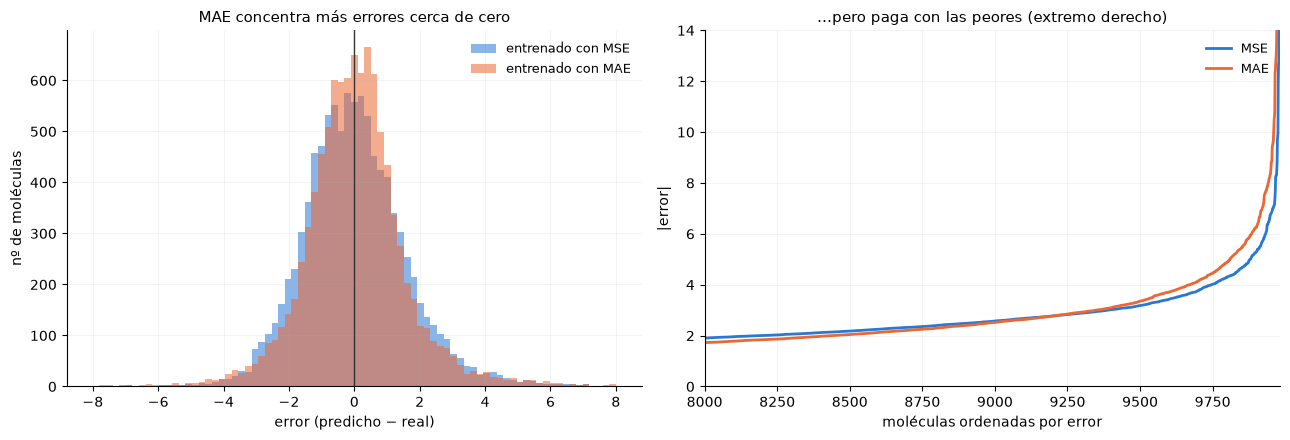

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# distribucion de los errores
bins = np.linspace(-8, 8, 80)
ax1.hist(pred_mse - y_np, bins=bins, alpha=0.55, color="#2a78d6", label="entrenado con MSE")
ax1.hist(pred_mae - y_np, bins=bins, alpha=0.55, color="#eb6834", label="entrenado con MAE")
ax1.axvline(0, color="#333", linewidth=1)
ax1.set_xlabel("error (predicho − real)"); ax1.set_ylabel("nº de moléculas")
ax1.set_title("MAE concentra más errores cerca de cero", fontsize=11)
ax1.legend(frameon=False, fontsize=9)

# error absoluto ordenado: se ve el intercambio
ax2.plot(np.sort(np.abs(pred_mse - y_np)), color="#2a78d6", linewidth=2, label="MSE")
ax2.plot(np.sort(np.abs(pred_mae - y_np)), color="#eb6834", linewidth=2, label="MAE")
ax2.set_xlabel("moléculas ordenadas por error"); ax2.set_ylabel("|error|")
ax2.set_title("...pero paga con las peores (extremo derecho)", fontsize=11)
ax2.legend(frameon=False, fontsize=9)
ax2.set_xlim(8000, 9982)
ax2.set_ylim(0, 14)

for ax in (ax1, ax2):
    ax.grid(alpha=0.2, linewidth=0.5)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig("../figuras/02_ej6_mse_vs_mae.png", dpi=150)
plt.show()

**El resultado, que es exactamente el intercambio que se predijo en 2.3.5:**

| Entrenado con | MAE | RMSE | mediana \|error\| | % con error < 1 |
|---|---|---|---|---|
| MSE | 1.229 | **1.658** | 0.983 | 51.0 % |
| MAE | **1.176** | 1.810 | **0.835** | **57.7 %** |

**Cada uno gana en su propia métrica.** No es casualidad ni un empate raro: es la definición de
optimizar. Si entrenas minimizando el MAE, obtienes el modelo con el MAE más bajo posible — a costa
del RMSE, y al revés.

Las dos columnas que he añadido enseñan **dónde** está la diferencia:

- **El MAE afina el grueso.** Su error mediano es 0.835 frente a 0.983, y acierta dentro de una
  unidad de log en el **57.7 %** de las moléculas frente al 51.0 % del MSE. Seis puntos porcentuales
  más de moléculas bien predichas.
- **Y lo paga en los desastres.** Sumando los **100 peores** errores absolutos: 928 con MAE frente
  a 680 con MSE. La peor predicción de todas es de **35.7** unidades con MAE y de 23.0 con MSE.

Al MSE, un error de 35 le cuesta 1225 en la pérdida, así que hace lo que sea por evitarlo aunque
tenga que empeorar mil predicciones normales. Al MAE le cuesta 35 y no se molesta.

**La lección práctica: la función de pérdida no es un detalle técnico, es la definición de qué
significa "equivocarse".** Elegirla es una decisión del problema, no del algoritmo:

- **MSE** si un error grande es desproporcionadamente malo (te la juegas con un compuesto y no
  puedes permitirte un fallo de 5 órdenes de magnitud).
- **MAE** si tienes outliers o medidas dudosas que no quieres que manden, y te interesa acertar
  en el caso típico.

Con AqSolDB, donde sabemos que hay mezclas con descriptores absurdos y medidas de fiabilidad
desigual, **el MAE es posiblemente la elección más sensata**, aunque el libro use MSE (que es el
estándar y tiene mejores propiedades matemáticas).

**Sobre la derivada en cero.** El valor absoluto tiene un pico en 0 donde la derivada no existe. En
teoría es un problema; en la práctica no, por dos razones: la probabilidad de caer exactamente en
$\hat{y} = y$ con floats es nula, y JAX devuelve un **subgradiente** (uno de los valores válidos)
si ocurre. Sí se nota de otra forma: el gradiente del MAE es $\pm 1$ **siempre**, sin importar lo
grande que sea el error, así que el entrenamiento avanza a paso constante y necesita más
iteraciones (3000 aquí frente a 2000 del MSE).

### Ejercicio 7 — el efecto del tamaño de batch

> Entrena con batch sizes 1, 8, 32, 256 y 1024. Dibuja las curvas en escala log y analiza.

Antes de dibujar nada hay que resolver una trampa del enunciado: **¿comparadas cómo?** Con batch 1
das 9982 actualizaciones por época y con batch 1024 solo 9. Son dos ejes distintos:

- **Por número de actualizaciones** → mide la calidad de cada paso.
- **Por época** (misma cantidad de datos vistos) → mide el progreso por unidad de cómputo.

Son comparaciones distintas y dan conclusiones distintas. Hacemos las dos.

In [9]:
def entrenar_sgd(eta, batch_size, epocas, seed=0):
    """Devuelve (w, b, pérdida sobre TODO el dataset tras cada actualización)."""
    N = X_std.shape[0]
    w, b = jnp.zeros(17), 0.0
    historial = []
    rng = np.random.default_rng(seed)
    for _ in range(epocas):
        orden = rng.permutation(N)
        for inicio in range(0, N - batch_size + 1, batch_size):
            idx = orden[inicio:inicio + batch_size]
            gw, gb = loss_grad(w, b, X_std[idx], y[idx])
            w, b = w - eta * gw, b - eta * gb
            historial.append(float(loss_wrapper(w, b, X_std, y)))
    return w, b, historial


# primero: el mismo eta para todos, a ver que pasa
print("con eta = 0.01 (el que funciona bien para batch 32):")
for bs in [1, 8, 32, 256, 1024]:
    _, _, h = entrenar_sgd(0.01, bs, 1)
    estado = "DIVERGE" if h[-1] > 14 else ""
    print(f"  batch {bs:5d}: {len(h):5d} actualizaciones, loss final = {h[-1]:12.4f}  {estado}")

con eta = 0.01 (el que funciona bien para batch 32):


  batch     1:  9982 actualizaciones, loss final =   16665.7598  DIVERGE


  batch     8:  1247 actualizaciones, loss final =       2.9703  


  batch    32:   311 actualizaciones, loss final =       3.3356  
  batch   256:    38 actualizaciones, loss final =       5.1334  


  batch  1024:     9 actualizaciones, loss final =       9.9483  


**Primer hallazgo, y no es el que uno espera: con batch 1 el entrenamiento explota.**

La razón es la varianza del gradiente. El gradiente de un batch es una estimación ruidosa del
gradiente verdadero, y su **varianza es inversamente proporcional al tamaño del batch**: con 1024
moléculas promedias mucho ruido y la estimación es fiable; con 1 molécula el gradiente es el de esa
molécula concreta. Si te toca una de las mezclas raras de 2.3.9, con `MolWt = 5299`, ese gradiente
es gigantesco y te manda a tomar viento.

**Corolario práctico que hay que recordar: batch más pequeño exige learning rate más pequeño.** Es
la primera cosa que hay que tocar si bajas el batch size y el entrenamiento deja de funcionar. (La
regla heurística habitual va en el otro sentido: si **multiplicas** el batch por $k$, puedes
multiplicar $\eta$ por $k$ o por $\sqrt{k}$.)

Repetimos con un $\eta$ que aguanten todos:

In [10]:
resultados = {}
for bs in [1, 8, 32, 256, 1024]:
    resultados[bs] = entrenar_sgd(0.001, bs, 1)
    print(f"  batch {bs:5d}: {len(resultados[bs][2]):5d} actualizaciones, "
          f"loss final = {resultados[bs][2][-1]:7.4f}")

  batch     1:  9982 actualizaciones, loss final =  3.0811


  batch     8:  1247 actualizaciones, loss final =  3.2030
  batch    32:   311 actualizaciones, loss final =  5.8109
  batch   256:    38 actualizaciones, loss final = 11.9151
  batch  1024:     9 actualizaciones, loss final = 13.3963


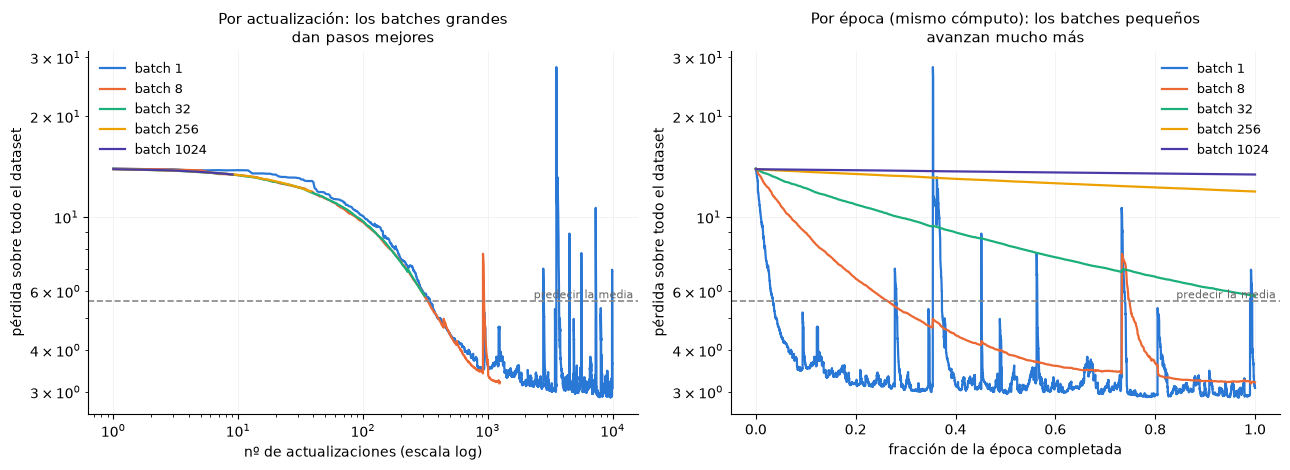

In [11]:
colores = {1: "#2a78d6", 8: "#eb6834", 32: "#1baf7a", 256: "#eda100", 1024: "#4a3aa7"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

for bs, (_, _, h) in resultados.items():
    n = len(h)
    ax1.plot(np.arange(1, n + 1), h, color=colores[bs], linewidth=1.6, label=f"batch {bs}")
    ax2.plot(np.linspace(0, 1, n), h, color=colores[bs], linewidth=1.6, label=f"batch {bs}")

ax1.set_xscale("log"); ax1.set_xlabel("nº de actualizaciones (escala log)")
ax1.set_title("Por actualización: los batches grandes\ndan pasos mejores", fontsize=11)

ax2.set_xlabel("fracción de la época completada")
ax2.set_title("Por época (mismo cómputo): los batches pequeños\navanzan mucho más", fontsize=11)

for ax in (ax1, ax2):
    ax.set_yscale("log")
    ax.set_ylabel("pérdida sobre todo el dataset")
    ax.axhline(5.608, color="#888", linestyle="--", linewidth=1.2)
    ax.text(ax.get_xlim()[1], 5.608, " predecir la media ", fontsize=8, color="#666",
            ha="right", va="bottom")
    ax.legend(frameon=False, fontsize=9)
    ax.grid(alpha=0.2, linewidth=0.5)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig("../figuras/02_ej7_batch_sizes.png", dpi=150)
plt.show()

Con $\eta = 0.001$ y **una época** para todos:

| Batch | Actualizaciones | Pérdida final |
|---|---|---|
| 1 | 9982 | **3.08** |
| 8 | 1247 | 3.20 |
| 32 | 311 | 5.81 |
| 256 | 38 | 11.92 |
| 1024 | 9 | 13.40 |

**Panel derecho (por época): los batches pequeños ganan de calle.** Con el mismo cómputo —una
pasada por los datos— el batch 1 llega a 3.08 y el batch 1024 se queda en 13.40, que es casi el
punto de partida. Normal: el batch 1024 solo ha tenido **9 oportunidades** de mover los pesos.

**Panel izquierdo (por actualización): se invierte.** A igual número de pasos, los batches grandes
van por debajo, porque cada paso suyo es más fiable. Pero cada paso les cuesta 1024 veces más
cálculo.

**Y el ruido:** mira lo peludas que son las curvas de batch 1 y 8 frente a la de 1024. Es el mismo
fenómeno de la curva de 2.3.7, ahora comparado lado a lado.

**La conclusión, que es por qué 32-256 es lo que usa todo el mundo:**

| | Batch pequeño | Batch grande |
|---|---|---|
| Actualizaciones por época | muchas | pocas |
| Progreso por unidad de cómputo | **mejor** | peor |
| Ruido del gradiente | alto | bajo |
| Learning rate admisible | bajo | alto |
| Aprovechamiento de la GPU | malo (infrautilizada) | **bueno** (paralelismo) |
| Escapar de mínimos malos | **ayuda** | no ayuda |

El tamaño de batch es un compromiso entre **frecuencia de actualización** y **calidad de cada
actualización**, con el hardware decidiendo el suelo: un batch de 1 deja la GPU parada, porque está
diseñada para hacer miles de multiplicaciones a la vez. Por eso el óptimo práctico está en el medio,
y por eso siempre ves potencias de 2 entre 32 y 512.

---
## 2.6.4 Clustering

### Ejercicio 8 — ¿qué representan las "etiquetas" en clustering?

**La respuesta: nada más que un nombre.** Son **identificadores nominales**, no cantidades.

Cuando `kmeans.fit_predict` devuelve un 3 para una molécula, ese 3 significa "pertenece al grupo que
el algoritmo numeró como 3". No significa que sea más de nada. En concreto, **no** puedes:

- **Ordenarlas.** El cluster 3 no es "mayor" que el 1. No hay orden.
- **Hacer aritmética.** La media entre el cluster 0 y el 2 no es el cluster 1.
- **Compararlas entre ejecuciones.** Y esto es lo más importante.

Ese último punto es el que se demuestra ejecutando k-means con distintas semillas:

In [12]:
for semilla in [0, 1, 2]:
    km = sklearn.cluster.KMeans(n_clusters=4, n_init=10, random_state=semilla)
    etiquetas = km.fit_predict(np.array(X_std))
    tam = np.bincount(etiquetas)
    pesos = [round(soldata.loc[etiquetas == c, "MolWt"].mean()) for c in range(4)]
    print(f"semilla {semilla}:  tamaños = {tam}   MolWt medio de cada cluster = {pesos}")

semilla 0:  tamaños = [6012 3103  280  587]   MolWt medio de cada cluster = [178, 358, 971, 357]
semilla 1:  tamaños = [6021 3104  582  275]   MolWt medio de cada cluster = [178, 358, 358, 977]
semilla 2:  tamaños = [5991  283 3125  583]   MolWt medio de cada cluster = [178, 967, 357, 358]


Míralo con atención. Las tres ejecuciones encuentran **exactamente los mismos cuatro grupos**
—reconocibles por su peso molecular medio: ~178, ~358, ~358 y ~970— pero **con los números
cambiados de sitio**:

| Semilla | cluster 0 | cluster 1 | cluster 2 | cluster 3 |
|---|---|---|---|---|
| 0 | 178 | 358 | **971** | 357 |
| 1 | 178 | 358 | 358 | **977** |
| 2 | 178 | **967** | 357 | 358 |

El grupo de las moléculas gigantes es el 2 con una semilla, el 3 con otra y el 1 con otra. **La
etiqueta es arbitraria; la partición es la misma.**

Consecuencias prácticas:

- **Nunca guardes números de cluster** entre ejecuciones sin guardar también los centroides. Si
  vuelves a ejecutar, tu "cluster 2" ya no es el mismo.
- **No se puede medir "accuracy" de un clustering** comparando etiquetas con unas de referencia,
  porque no hay correspondencia. Para eso hay métricas invariantes a permutaciones, como el
  *adjusted Rand index*.
- **Para que un cluster signifique algo hay que caracterizarlo**, como hicimos en 2.4 sacando la
  tabla de descriptores medios. "Cluster 3" no informa; "el grupo de los policíclicos saturados,
  MolWt 357, 2.7 anillos saturados" sí.

Esta es, en el fondo, la diferencia entre supervisado y no supervisado: en supervisado, $y = -3.2$
significa algo fuera del modelo. En no supervisado, la salida solo tiene sentido **dentro** del
resultado concreto que has obtenido.

### Ejercicio 9 — dos razones para NO meter las labels como feature del clustering

**Razón 1: destruye el argumento, lo vuelve circular.**

Lo interesante de 2.4 fue precisamente esto: el clustering **no vio la solubilidad** y aun así los
grupos salieron con solubilidades medias muy distintas (de −2.00 a −4.41). Eso es evidencia real de
que la estructura de las features guarda relación con la propiedad que queremos predecir — y es la
justificación de todo el *pretraining* del capítulo 20.

Si metes la solubilidad como feature número 18, esa conclusión se evapora. Los clusters tendrían
solubilidades distintas **porque los has agrupado por solubilidad**. Habrías construido una máquina
de meter datos en cajones de solubilidad y luego te asombrarías de que los cajones tengan
solubilidades distintas.

**Razón 2: te impide usarlo con datos sin etiquetar, que es para lo que sirve.**

El clustering vale justo donde no hay etiquetas. Si tu modelo de clusters necesita la solubilidad
para asignar grupo, **no puedes asignar grupo a una molécula nueva** — y si tuvieras su solubilidad,
no necesitarías nada de esto. El único caso de uso queda destruido.

Y hay un corolario serio: si usas los clusters para **separar train y test** (lo que veremos en el
capítulo 3), unos clusters construidos con las labels hacen que la partición dependa de las
respuestas. Eso es **data leakage** de manual: tu conjunto de test deja de ser independiente y el
rendimiento que midas será optimista.

**Razón 3 (de regalo, más técnica): la escala.** k-means agrupa por distancia euclídea, y ahí cada
feature pesa según su magnitud. Meter una label entre 17 features obliga a decidir cuánto pesa esa
dimensión frente a las otras — y esa decisión es completamente arbitraria. Ponla con una escala y
los clusters son bandas de solubilidad; ponla con otra y no influye nada. No hay criterio para elegir.

### Ejercicio 10 — el mapa PCA coloreado por fuente experimental

> Colorea la proyección PCA por la columna `Group` en vez de por cluster. ¿Se parece a lo que
> encontró k-means? ¿Qué implicaciones tiene?

`Group` indica de qué **fuente experimental** procede cada dato dentro de AqSolDB, que es una base
de datos **curada a partir de nueve fuentes distintas**. Es una columna de metadatos: no es química
de la molécula, es procedencia del dato.

In [13]:
pca = sklearn.decomposition.PCA(n_components=2)
coords = pca.fit_transform(np.array(X_std))
clusters = sklearn.cluster.KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(np.array(X_std))

grupos = sorted(soldata["Group"].unique())
print(f"{'Group':>6s} {'n':>6s} {'%':>6s} {'sol. media':>11s} {'std':>6s} {'PC1 medio':>10s} {'PC2 medio':>10s}")
print("-" * 60)
for g in grupos:
    m = (soldata["Group"] == g).values
    print(f"{g:>6s} {m.sum():6d} {100 * m.mean():5.1f}% {soldata['Solubility'][m].mean():11.2f} "
          f"{soldata['Solubility'][m].std():6.2f} {coords[m, 0].mean():10.2f} {coords[m, 1].mean():10.2f}")

 Group      n      %  sol. media    std  PC1 medio  PC2 medio
------------------------------------------------------------
    G1   7746  77.6%       -2.86   2.38       0.17      -0.03
    G2    235   2.4%       -4.05   2.35       0.63       0.85
    G3   1182  11.8%       -2.79   2.30      -0.57       0.05
    G4    183   1.8%       -3.81   2.26      -0.55      -0.07
    G5    636   6.4%       -2.68   2.27      -1.04      -0.04


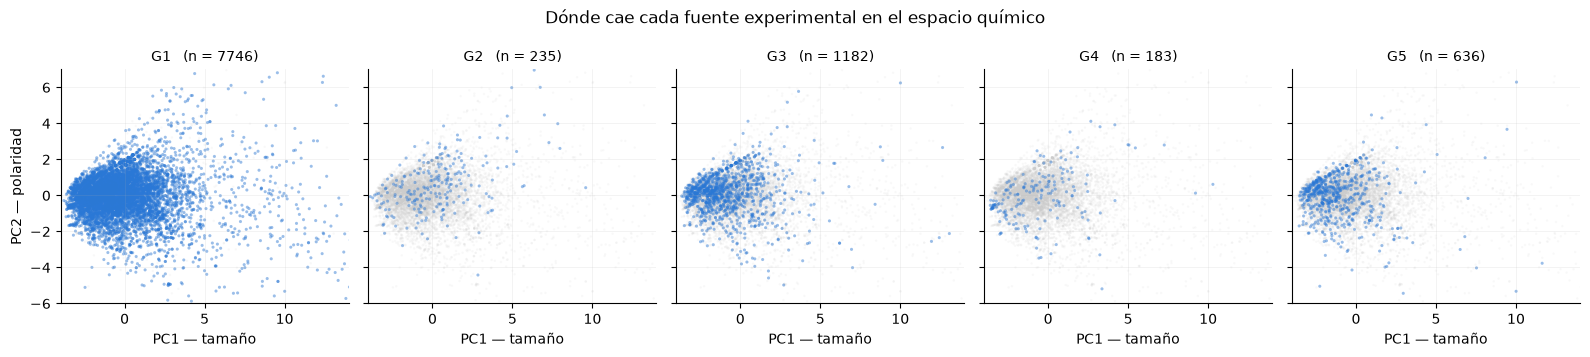

% de cada fuente que cae en cada cluster:
       cluster 0  cluster 1  cluster 2  cluster 3
Group                                            
G1          57.7       33.0        3.2        6.1
G2          41.7       50.2        2.6        5.5
G3          71.0       22.5        1.5        5.0
G4          62.3       30.6        1.6        5.5
G5          76.9       16.7        1.4        5.0

reparto global de clusters (%): [60.2, 31.1, 2.8, 5.9]


In [14]:
# small multiples: cada fuente sobre el fondo gris de todas las moleculas
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6), sharex=True, sharey=True)

for ax, g in zip(axes, grupos):
    m = (soldata["Group"] == g).values
    ax.scatter(coords[:, 0], coords[:, 1], s=3, alpha=0.12, color="#cccccc",
               edgecolors="none", rasterized=True)
    ax.scatter(coords[m, 0], coords[m, 1], s=5, alpha=0.45, color="#2a78d6",
               edgecolors="none", rasterized=True)
    ax.set_title(f"{g}   (n = {m.sum()})", fontsize=10)
    ax.set_xlabel("PC1 — tamaño")
    ax.set_xlim(-4, 14); ax.set_ylim(-6, 7)
    ax.grid(alpha=0.2, linewidth=0.5)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

axes[0].set_ylabel("PC2 — polaridad")
fig.suptitle("Dónde cae cada fuente experimental en el espacio químico", fontsize=12)
fig.tight_layout()
fig.savefig("../figuras/02_ej10_grupos.png", dpi=150)
plt.show()

# ¿coinciden fuentes y clusters?
tabla = pd.crosstab(soldata["Group"], clusters, normalize="index") * 100
tabla.columns = [f"cluster {c}" for c in tabla.columns]
print("% de cada fuente que cae en cada cluster:")
print(tabla.round(1).to_string())
print("\nreparto global de clusters (%):",
      (np.bincount(clusters) / len(clusters) * 100).round(1).tolist())

#### La respuesta

**¿Se parece a los clusters de k-means? No, o muy poco.** Las cinco fuentes ocupan **la misma
región** del espacio químico; ninguna forma una isla propia. La tabla lo confirma: todas reparten
sus moléculas entre los cuatro clusters, y en proporciones parecidas al reparto global
(60 / 31 / 3 / 6).

Es un resultado tranquilizador: significa que AqSolDB **no es** una colcha de retales donde cada
fuente aporta una familia química distinta. Las fuentes se solapan.

**Pero hay sesgos claros, y no son despreciables:**

| Fuente | n | Solubilidad media | PC1 medio | % en cluster 0 |
|---|---|---|---|---|
| G1 | 7746 (78 %) | −2.86 | +0.17 | 57.7 % |
| G2 | 235 | **−4.05** | **+0.63** | 41.7 % |
| G3 | 1182 | −2.79 | −0.57 | 71.0 % |
| G4 | 183 | −3.81 | −0.55 | 62.3 % |
| G5 | 636 | **−2.68** | **−1.04** | **76.9 %** |

- **G2 mide compuestos más grandes y bastante más insolubles** (−4.05 frente a −2.68 de G5). Casi
  1.4 unidades de log de diferencia en la media, más de la mitad de una desviación típica.
- **G5 tiene el PC1 más bajo de todos** (−1.04): son sistemáticamente moléculas más pequeñas, y
  el 77 % caen en el cluster de las sencillas.
- **G1 es el 78 % del dataset**, así que "la media global" es básicamente "la media de G1".

#### Las implicaciones, que es lo que pedía el ejercicio

**1. Partir train/test al azar puede engañarte.** Si una fuente concreta mide un tipo de molécula
y con un protocolo distinto, repartir sus moléculas entre train y test hace que el test contenga
casos casi idénticos a los de entrenamiento. Tu RMSE saldrá bonito y no te dirá nada sobre cómo
se comportará el modelo con química nueva. El **split por grupos** —entrenar con unas fuentes y
evaluar con otra— es una prueba mucho más dura y mucho más parecida al uso real. Es tema del
capítulo 3.

**2. El modelo puede aprender la fuente en vez de la química.** Si G2 mide sistemáticamente más
bajo, y sus moléculas tienden a ser grandes, el modelo puede estar captando en parte "esto huele a
protocolo de G2" disfrazado de "esto es grande". Con 78 % de los datos viniendo de G1, el modelo es
en realidad **un modelo de G1** con ruido de los demás.

**3. Hay una parte del error irreducible que es metodológica.** Dos laboratorios midiendo el mismo
compuesto no dan el mismo número — temperatura, pureza, criterio de saturación, tiempo de
equilibrado. Parte del 1.66 de RMSE que no conseguimos bajar **no es culpa del modelo**: es
discrepancia entre fuentes.

#### Una corrección a lo que dijimos en 2.3.2

Al ver el histograma sugerí que el "hombro" hacia −7 podía deberse a que hubiera otra fuente
experimental mezclada. **Con estos datos, esa hipótesis no se sostiene**: todas las fuentes tienen
distribuciones de solubilidad muy parecidas (desviaciones típicas entre 2.26 y 2.38), y la
fracción de moléculas por debajo de −6 es del 11.5 % en G1 frente al 11.4 % global. Solo G2 se
desvía de verdad (21.7 %), y son 235 moléculas: demasiado pocas para crear ese hombro.

Así que ese rasgo del histograma es estructura de los propios datos, no un artefacto de mezclar
fuentes.

---
## Resumen: lo que enseña cada ejercicio

| Ej. | Tema | La idea que hay que retener |
|---|---|---|
| 1 | reducciones | `axis=k` = "el eje k desaparece"; la disparidad de escalas justifica estandarizar |
| 2 | datos sucios | el dataset tiene mezclas y sales con descriptores sumados — el mismo fallo que vimos en los residuos |
| 3 | modelos lineales | "lineal" = lineal **en los parámetros**; la curva la ponen las features (base del cap. 5) |
| 4 | einsum | `"bi,i->b"`: se suma sobre `i` porque no está en la salida; `b` se conserva |
| 5 | escalas | escalar las labels **no** cambia el learning rate: el Hessiano del MSE solo depende de $X$ |
| 6 | funciones de pérdida | MSE y MAE dan modelos distintos; la pérdida define qué significa "equivocarse" |
| 7 | batch size | compromiso entre frecuencia y calidad de cada paso; batch pequeño exige $\eta$ pequeño |
| 8 | etiquetas de cluster | son **nombres**, no cantidades; cambian en cada ejecución |
| 9 | metodología | meter la label en el clustering vuelve el argumento circular y provoca leakage |
| 10 | procedencia | las fuentes se solapan pero tienen sesgos; el split aleatorio puede mentir |

**Los tres que más van a pesar en el resto del libro:** el 3 (la no linealidad va en las features),
el 5 (por qué estandarizar features sí y labels no tanto) y el 10 (cómo partir los datos), que
enlaza directamente con el capítulo 3.